In [1]:
# Import Pandas module
# Import NumPy module
import numpy as np
import pandas as pd

# We will cover data visualization in more details later in the semester.
# For now the only visualization that we'll explore is histograms.
# Histograms are helpful for visually examining distribution of a particular variable

# The following line is a directive that tells matplotlib module to display
# generated graphs inline with the output of your code
%matplotlib inline 

# Import matplotlib module.  Matplotlib module allows us to generate graphs from data
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [3]:
# Import data file into a Pandas dataframe
df = pd.read_csv("../data/video_games.csv")

# Display the first 5 rows of the data
df.head()

,number,game,release_date,price,owners,developer,publisher,average_playtime,median_playtime,metascore
0,1,Half-Life 2,"Nov 16, 2004",9.99,"10,000,000 .. 20,000,000",Valve,Valve,110.0,66.0,96.0
1,3,Counter-Strike: Source,"Nov 1, 2004",9.99,"10,000,000 .. 20,000,000",Valve,Valve,236.0,128.0,88.0
2,21,Counter-Strike: Condition Zero,"Mar 1, 2004",9.99,"10,000,000 .. 20,000,000",Valve,Valve,10.0,3.0,65.0
3,47,Half-Life 2: Deathmatch,"Nov 1, 2004",4.99,"5,000,000 .. 10,000,000",Valve,Valve,0.0,0.0,NaN
4,36,Half-Life: Source,"Jun 1, 2004",9.99,"2,000,000 .. 5,000,000",Valve,Valve,0.0,0.0,NaN


In [4]:
df.dtypes

number                int64
game                 object
release_date         object
price               float64
owners               object
developer            object
publisher            object
average_playtime    float64
median_playtime     float64
metascore           float64
dtype: object

In [5]:
# Before cleaning your data or trying to figure out how to analyze it, it is always a
# good idea to understand what your data actually looks like
# describe() function of DataFrame allows us to view basic statistics about our data
df.describe()

,number,price,average_playtime,median_playtime,metascore
count,26688.000000,23593.000000,26679.000000,26676.000000,2850.000000
mean,2904.194170,8.947136,9.057274,5.159732,71.895439
std,2377.066421,12.164410,117.938246,68.911476,11.017788
min,1.000000,0.490000,0.000000,0.000000,20.000000
25%,821.000000,2.990000,0.000000,0.000000,66.000000
50%,2356.000000,5.990000,0.000000,0.000000,73.000000
75%,4523.250000,9.990000,0.000000,0.000000,80.000000
max,8846.000000,595.990000,5670.000000,3293.000000,98.000000


array([[<Axes: title={'center': 'number'}>,
        <Axes: title={'center': 'price'}>],
       [<Axes: title={'center': 'average_playtime'}>,
        <Axes: title={'center': 'median_playtime'}>],
       [<Axes: title={'center': 'metascore'}>, <Axes: >]], dtype=object)

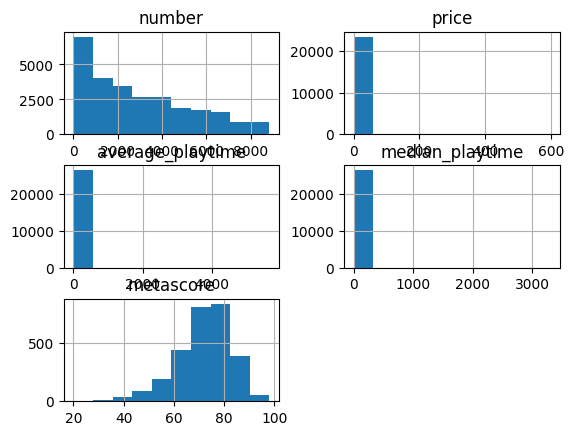

In [6]:
# Now let's generate histograms for all continuous variables to
# make sure that there are no issues with distributions and/or outliers.
df.hist()


<Axes: >

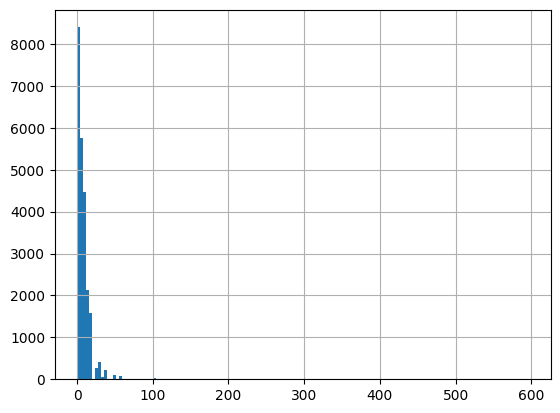

In [7]:
# Looking at histograms of all variables at the same time is a bit difficult,
# so let's generate a histogram for the variable that we are actually
# interested in examining
df["price"].hist(bins=150)


In [11]:
# In Pandas, using query to select a subset of the data is the faster option than 
# using loops to select data
q = "metascore < 80 & metascore > 70"
df_filtered = df.query(q)
df_filtered

,number,game,release_date,price,owners,developer,publisher,average_playtime,median_playtime,metascore
8,14,Beyond Divinity,"Apr 27, 2004",5.99,"500,000 .. 1,000,000",Larian Studios,Larian Studios,0.0,0.0,73.0
16,12,Soldiers: Heroes of World War II,"Jun 29, 2004",4.99,"100,000 .. 200,000",Best Way,1C Entertainment,0.0,0.0,77.0
29,11,Perimeter,"May 21, 2004",3.99,"20,000 .. 50,000",K-D Lab,1C Entertainment,0.0,0.0,77.0
30,15,Warlords Battlecry III,"May 17, 2004",9.99,"20,000 .. 50,000",Infinite Interactive,"Retroism, Enlight Software Limited",0.0,0.0,73.0
31,16,Men of Valor,"Nov 29, 2004",9.99,"20,000 .. 50,000",2015,THQ Nordic,0.0,0.0,71.0
...,...,...,...,...,...,...,...,...,...,...
19001,185,39 Days to Mars,"Apr 25, 2018",14.99,"0 .. 20,000",It's Anecdotal,It's Anecdotal,0.0,0.0,71.0
19002,187,I Hate Running Backwards,"May 22, 2018",14.99,"0 .. 20,000","Binx Interactive, Croteam Incubator, Croteam",Devolver Digital,0.0,0.0,71.0
19003,188,Leisure Suit Larry - Wet Dreams Don't Dry,"Nov 7, 2018",29.99,"0 .. 20,000",CrazyBunch,Assemble Entertainment,0.0,0.0,71.0
19004,189,Masters of Anima,"Apr 10, 2018",19.99,"0 .. 20,000",Passtech Games,Focus Home Interactive,0.0,0.0,71.0


In [10]:
# Building a dataframe row by row in Pandas is definitely not the a recommended solution
# if you really want to do something similar, a better solution is to create a list and
# convert the entire list to dataframe.
filtered_list = []
for idx, row in df.iterrows():
    if row['metascore'] < 80 and row['metascore'] > 70:
        filtered_list.append(row.to_dict())
df_filtered_prime = pd.DataFrame(filtered_list)
df_filtered_prime.head()

,number,game,release_date,price,owners,developer,publisher,average_playtime,median_playtime,metascore
0,14,Beyond Divinity,"Apr 27, 2004",5.99,"500,000 .. 1,000,000",Larian Studios,Larian Studios,0.0,0.0,73.0
1,12,Soldiers: Heroes of World War II,"Jun 29, 2004",4.99,"100,000 .. 200,000",Best Way,1C Entertainment,0.0,0.0,77.0
2,11,Perimeter,"May 21, 2004",3.99,"20,000 .. 50,000",K-D Lab,1C Entertainment,0.0,0.0,77.0
3,15,Warlords Battlecry III,"May 17, 2004",9.99,"20,000 .. 50,000",Infinite Interactive,"Retroism, Enlight Software Limited",0.0,0.0,73.0
4,16,Men of Valor,"Nov 29, 2004",9.99,"20,000 .. 50,000",2015,THQ Nordic,0.0,0.0,71.0


In [12]:
# Now let's check which values in the dataset are missing/empty
# Note that Pandas treats missing, empty, and null as pretty much the same thing
# isnull() function will render the entire DataFrame with False value in those
# records where the data IS NOT missing, and True where the value IS missing
df.isnull().describe()

,number,game,release_date,price,owners,developer,publisher,average_playtime,median_playtime,metascore
count,26688,26688,26688,26688,26688,26688,26688,26688,26688,26688
unique,1,2,1,2,1,2,2,2,2,2
top,False,False,False,False,False,False,False,False,False,True
freq,26688,26685,26688,23593,26688,26536,26568,26679,26676,23838


In [13]:
# As you can see, running isnull() on the entire dataframe produces
# too much data and it difficult to examine visually.  To summarize
# which columns have missing data, we can comibine isnull() with sum()

df.isnull().sum()

number                  0
game                    3
release_date            0
price                3095
owners                  0
developer             152
publisher             120
average_playtime        9
median_playtime        12
metascore           23838
dtype: int64

In [ ]:
# you can get a sub dataframe with all the rows that have at list one null data.

df_nan = df[df.isnull().any(axis=1)]
df_nan

,number,game,release_date,price,owners,developer,publisher,average_playtime,median_playtime,metascore
3,47,Half-Life 2: Deathmatch,"Nov 1, 2004",4.99,"5,000,000 .. 10,000,000",Valve,Valve,0.0,0.0,NaN
4,36,Half-Life: Source,"Jun 1, 2004",9.99,"2,000,000 .. 5,000,000",Valve,Valve,0.0,0.0,NaN
5,52,CS2D,"Dec 24, 2004",NaN,"1,000,000 .. 2,000,000",Unreal Software,Unreal Software,16.0,10.0,NaN
9,40,Hitman: Contracts,"Apr 20, 2004",8.99,"500,000 .. 1,000,000",Io-Interactive A/S,Io-Interactive A/S,0.0,0.0,NaN
12,43,"STAR WARS Battlefront (Classic, 2004)","Sep 21, 2004",9.99,"200,000 .. 500,000",Pandemic Studios,"Lucasfilm, LucasArts, Disney",0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...
26683,8842,Draw Near,"Apr 15, 2018",NaN,"0 .. 20,000",Omniscience,Taiga Nishimura,0.0,0.0,NaN
26684,8843,Alone,"May 1, 2018",0.99,"0 .. 20,000",Killed Pixel Games,Killed Pixel Games,0.0,0.0,NaN
26685,8844,qrth-phyl,"Jul 19, 2018",4.99,"0 .. 20,000",Verran,Verran,0.0,0.0,NaN
26686,8845,Guns and Notes,"Jan 26, 2018",9.99,"0 .. 20,000",VR Factory,VR Factory,0.0,0.0,NaN


In [15]:
# Now let's deal with missing values

# Solution 1: Remove rows with empty values
# If there are only a few null values and you know that deleting values will
# not cause adverse effects on your result, remove them from your DataFrame and
# store should be ok. But our case here is not ideal.

print("Missing values before dropping rows: ")
print(df.shape)

print("Missing values after dropping rows: ")
print(df.dropna().shape)

Missing values before dropping rows: 
(26688, 10)
Missing values after dropping rows: 
(2668, 10)


In [16]:
# The problem in this case is the metascore column with 23838 missing values.
# Depending on the analysis, we may want to drop the column entirely, or just stick to the
# remaining 2668 rows if we are interested in metascore.

df_no_score = df.drop(columns=["metascore"])
df_score = df.dropna(subset=["metascore"])

In [17]:
df_score.describe()

,number,price,average_playtime,median_playtime,metascore
count,2850.000000,2691.000000,2848.000000,2845.000000,2850.000000
mean,160.196140,15.904783,46.608497,25.609490,71.895439
std,397.049477,10.555365,278.271662,151.974352,11.017788
min,1.000000,0.490000,0.000000,0.000000,20.000000
25%,51.000000,9.990000,0.000000,0.000000,66.000000
50%,116.000000,14.990000,0.000000,0.000000,73.000000
75%,200.000000,19.990000,0.000000,0.000000,80.000000
max,8251.000000,59.990000,5450.000000,3293.000000,98.000000


In [18]:
df_score.isnull().sum()

number                0
game                  1
release_date          0
price               159
owners                0
developer            11
publisher             9
average_playtime      2
median_playtime       5
metascore             0
dtype: int64

In [19]:
pd.isna(df_score).sum()

number                0
game                  1
release_date          0
price               159
owners                0
developer            11
publisher             9
average_playtime      2
median_playtime       5
metascore             0
dtype: int64

In [20]:
df_score.describe()

,number,price,average_playtime,median_playtime,metascore
count,2850.000000,2691.000000,2848.000000,2845.000000,2850.000000
mean,160.196140,15.904783,46.608497,25.609490,71.895439
std,397.049477,10.555365,278.271662,151.974352,11.017788
min,1.000000,0.490000,0.000000,0.000000,20.000000
25%,51.000000,9.990000,0.000000,0.000000,66.000000
50%,116.000000,14.990000,0.000000,0.000000,73.000000
75%,200.000000,19.990000,0.000000,0.000000,80.000000
max,8251.000000,59.990000,5450.000000,3293.000000,98.000000


In [21]:
df_score[df_score.isnull().any(axis=1)].sample(10)

,number,game,release_date,price,owners,developer,publisher,average_playtime,median_playtime,metascore
2048,6,Spelunky,"Aug 8, 2013",14.99,"1,000,000 .. 2,000,000",NaN,Mossmouth,10.0,3.0,90.0
1940,183,Fray: Reloaded Edition,"Jun 19, 2012",NaN,"0 .. 20,000",Brain Candy,Brain Candy,0.0,0.0,27.0
2602,23,Outland,"Sep 29, 2014",NaN,"1,000,000 .. 2,000,000",Housemarque,Housemarque,0.0,0.0,83.0
2666,206,Prime World,"Mar 31, 2014",NaN,"500,000 .. 1,000,000",Nival,Nival,0.0,0.0,65.0
1114,127,Vancouver 2010 - The Official Video Game of th...,"Feb 18, 2010",NaN,"0 .. 20,000",Eurocom,SEGA,0.0,0.0,57.0
705,93,Eschalon: Book I,"Feb 10, 2009",NaN,"50,000 .. 100,000",Basilisk Games,Basilisk Games,0.0,0.0,75.0
1274,25,EverQuest II,"Dec 7, 2011",NaN,"500,000 .. 1,000,000",Daybreak Game Company,Daybreak Game Company,0.0,0.0,83.0
10982,145,FOR HONOR,"Feb 13, 2017",14.99,"2,000,000 .. 5,000,000","Ubisoft Montreal, Ubisoft Quebec, Ubisoft Toro...",Ubisoft,NaN,NaN,76.0
1624,83,Stronghold Kingdoms,"Feb 27, 2012",NaN,"1,000,000 .. 2,000,000",FireFly Studios,FireFly Studios,0.0,0.0,75.0
4335,264,Oh...Sir! Prototype,"Dec 21, 2015",NaN,"100,000 .. 200,000",Vile Monarch,Good Shepherd Entertainment,0.0,0.0,64.0


<Axes: >

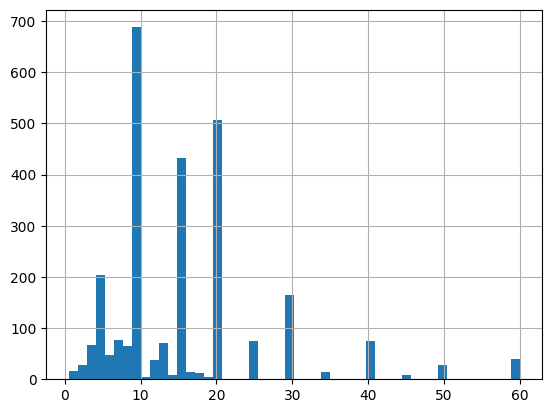

In [23]:
# Let's generate a density plot
df_score["price"].hist(bins=50)

In [24]:
# Solution 2: Fill missing values with a mean or medianvalue of a given column

# Find the mean
df_score["price"].median()

np.float64(14.99)

In [26]:
# Fill missing values with a mean (average) value of a given column
# Note the inplace=True parameter - that means that we are overwriting the data
# in the existing dataset
df_no_score["price"].fillna(df_no_score["price"].median(), inplace=True)
df_no_score.sample(10)

,number,game,release_date,price,owners,developer,publisher,average_playtime,median_playtime
22919,4605,Bad Day Betsy,"Sep 24, 2018",3.99,"0 .. 20,000",The DF Team,"Zero Brain, LLC",0.0,0.0
4363,546,Lilly and Sasha: Curse of the Immortals,"Apr 28, 2015",5.99,"100,000 .. 200,000",John Wizard,John Wizard,0.0,0.0
3064,217,The Impossible Game,"May 8, 2014",4.99,"50,000 .. 100,000",Grip Games,FlukeDude,0.0,0.0
19718,1058,Freezeer,"Jun 21, 2018",0.49,"0 .. 20,000",NedoStudio,NedoStudio,0.0,0.0
8448,457,Blast Brawl 2: Bloody Boogaloo,"Oct 26, 2016",14.99,"0 .. 20,000",Mind's Eye Games,Mind's Eye Games,0.0,0.0
6811,2729,SolForge,"Jul 25, 2016",5.99,"200,000 .. 500,000",Stone Blade Entertainment,Stone Blade Entertainment,0.0,0.0
11254,5956,The Last Hope: Trump vs Mafia - North Korea,"Jan 20, 2017",0.49,"200,000 .. 500,000","Atomic Fabrik, Cristian Manolachi","Atomic Fabrik, Cristian Manolachi",0.0,0.0
19710,1048,Up And Up,"May 21, 2018",0.99,"0 .. 20,000",Junitre Works,Junitre Works,0.0,0.0
5408,501,Expander,"Dec 1, 2015",2.99,"0 .. 20,000",All Civilized Planets,All Civilized Planets,0.0,0.0
19894,1254,Lawless Lands,"Sep 10, 2018",7.99,"0 .. 20,000",Corrosive Studios LLC,Corrosive Studios LLC,0.0,0.0


In [27]:
# but actually, it's better for us just drop all rows with missing values
df_score.dropna(subset=["price", "average_playtime", "median_playtime"], inplace=True)
df_score.sample(10)

/tmp/ipykernel_7491/1837140305.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_score.dropna(subset=["price", "average_playtime", "median_playtime"], inplace=True)


,number,game,release_date,price,owners,developer,publisher,average_playtime,median_playtime,metascore
18161,17,魔物讨伐团,"Aug 15, 2018",6.49,"50,000 .. 100,000",Nerdook Productions,Surefire.Games,0.0,0.0,86.0
11889,129,Battlestar Galactica Deadlock,"Aug 31, 2017",39.99,"20,000 .. 50,000",Black Lab Games,Slitherine Ltd.,0.0,0.0,77.0
4535,159,0RBITALIS,"May 28, 2015",9.99,"50,000 .. 100,000",Alan Zucconi,Mastertronic,0.0,0.0,73.0
11930,325,Don't Knock Twice,"Sep 5, 2017",19.99,"20,000 .. 50,000",Wales Interactive,Wales Interactive,0.0,0.0,56.0
3534,242,The Sun at Night,"Aug 1, 2014",4.99,"0 .. 20,000",Minicore Studios,Minicore Studios,0.0,0.0,59.0
668,40,AaAaAA!!! - A Reckless Disregard for Gravity,"Sep 3, 2009",9.99,"100,000 .. 200,000","Dejobaan Games, LLC","Dejobaan Games, LLC",0.0,0.0,81.0
6474,7,DARK SOULS III,"Apr 11, 2016",59.99,"2,000,000 .. 5,000,000","FromSoftware, Inc.","FromSoftware, Inc., BANDAI NAMCO Entertainment",868.0,1066.0,89.0
18049,244,Bus Simulator 18,"Jun 13, 2018",34.99,"100,000 .. 200,000",stillalive studios,astragon Entertainment,0.0,0.0,67.0
4785,147,Ceres,"Oct 16, 2015",19.99,"20,000 .. 50,000",Jötunn Games,Iceberg Interactive,0.0,0.0,74.0
1938,180,Clan of Champions,"Oct 30, 2012",1.99,"0 .. 20,000",ACQUIRE Corp.,"NIS America, Inc.",0.0,0.0,42.0


---


In [28]:
# Now let's figure out how to deal with discrete values
# Gender is a non-numeric (discrete) column, so we cannot use
# mean, median, or mode to replace the missing value
# A (somewhat) acceptable solution is to replace missing values with
# the most frequently occurring value

# Let's find out the number of missing values in the "gender" column
df_score["publisher"].isnull().sum()


np.int64(7)

In [29]:
df_score["publisher"].value_counts()

publisher
Ubisoft                    82
THQ Nordic                 53
Devolver Digital           47
Square Enix                44
Paradox Interactive        43
                           ..
grapefrukt games            1
Glitchy Pixel               1
Flying Wild Hog             1
Naiad Entertainment LLC     1
Jason Oda                   1
Name: count, Length: 1132, dtype: int64

In [36]:
# You can use Pandas' groupby() function to group by and aggregate your DataFrame
# by a particular column or a set of columns

# Let's group by gender and aggregate by mean and count
df_score.groupby(["publisher"]).agg({"publisher": "count"})

,publisher
publisher,
10tons Ltd,4
11 bit studios,9
11Sheep,1
"13AM Shipping Solutions, 13AM Games",1
17-BIT,2
...,...
nextReality Games,1
teedoubleuGAMES,1
tinyBuild,13


In [43]:
# This doesn't look that nice, both columns are named publisher. It will be a nightmare to
# use this dataframe to do any further analysis.

# let's make it prettier:
df_publisher = df_score.groupby(["publisher"]).agg(
    count=pd.NamedAgg(column="publisher", aggfunc="count")
).reset_index()
df_publisher.sort_values('count', ascending=False)

,publisher,count
1016,Ubisoft,82
932,THQ Nordic,53
271,Devolver Digital,47
890,Square Enix,44
713,Paradox Interactive,43
...,...,...
481,Illwinter Game Design,1
484,Indie Light,1
485,IndieGala,1
486,IndiePub,1


In [46]:
# Now that we know that "Ubisoft" occurs more frequently...
df_score_ubi = df_score["publisher"].fillna("Ubisoft")
df_score_ubi

0                                   Valve
1                                   Valve
2                                   Valve
6                        Epic Games, Inc.
7                             id Software
                       ...               
21446    Dark Illusions Entertainment LLC
23311                 Neko Climax Studios
23367                           RewindApp
26038                       SmallSqurriel
26149                           RewindApp
Name: publisher, Length: 2668, dtype: object

In [45]:
df_score = df_score.dropna()
df_score

,number,game,release_date,price,owners,developer,publisher,average_playtime,median_playtime,metascore
0,1,Half-Life 2,"Nov 16, 2004",9.99,"10,000,000 .. 20,000,000",Valve,Valve,110.0,66.0,96.0
1,3,Counter-Strike: Source,"Nov 1, 2004",9.99,"10,000,000 .. 20,000,000",Valve,Valve,236.0,128.0,88.0
2,21,Counter-Strike: Condition Zero,"Mar 1, 2004",9.99,"10,000,000 .. 20,000,000",Valve,Valve,10.0,3.0,65.0
6,2,Unreal Tournament 2004: Editor's Choice Edition,"Mar 16, 2004",14.99,"500,000 .. 1,000,000","Epic Games, Inc.","Epic Games, Inc.",0.0,0.0,93.0
7,4,DOOM 3,"Aug 3, 2004",4.99,"500,000 .. 1,000,000",id Software,id Software,0.0,0.0,87.0
...,...,...,...,...,...,...,...,...,...,...
21446,2972,SUPER KINKY,"Jul 6, 2018",1.99,"0 .. 20,000",Dark Illusions Entertainment LLC,Dark Illusions Entertainment LLC,0.0,0.0,70.0
23311,5052,DEEP SPACE WAIFU: NEKOMIMI,"Dec 18, 2018",1.99,"0 .. 20,000",Neko Climax Studios,Neko Climax Studios,0.0,0.0,98.0
23367,5133,Hentai Dojo,"Aug 24, 2018",0.49,"0 .. 20,000",RewindApp,RewindApp,0.0,0.0,65.0
26038,8118,Story of Eve - A Hero's Study,"Oct 16, 2018",2.99,"0 .. 20,000",SmallSqurriel,SmallSqurriel,0.0,0.0,87.0


In [47]:
# after dropping rows with missing values, the indexes are no longer sequential, there are gaps
# let's reset the index
df_score.reset_index(drop=True, inplace=True)
df_score

,number,game,release_date,price,owners,developer,publisher,average_playtime,median_playtime,metascore
0,1,Half-Life 2,"Nov 16, 2004",9.99,"10,000,000 .. 20,000,000",Valve,Valve,110.0,66.0,96.0
1,3,Counter-Strike: Source,"Nov 1, 2004",9.99,"10,000,000 .. 20,000,000",Valve,Valve,236.0,128.0,88.0
2,21,Counter-Strike: Condition Zero,"Mar 1, 2004",9.99,"10,000,000 .. 20,000,000",Valve,Valve,10.0,3.0,65.0
3,2,Unreal Tournament 2004: Editor's Choice Edition,"Mar 16, 2004",14.99,"500,000 .. 1,000,000","Epic Games, Inc.","Epic Games, Inc.",0.0,0.0,93.0
4,4,DOOM 3,"Aug 3, 2004",4.99,"500,000 .. 1,000,000",id Software,id Software,0.0,0.0,87.0
...,...,...,...,...,...,...,...,...,...,...
2663,2972,SUPER KINKY,"Jul 6, 2018",1.99,"0 .. 20,000",Dark Illusions Entertainment LLC,Dark Illusions Entertainment LLC,0.0,0.0,70.0
2664,5052,DEEP SPACE WAIFU: NEKOMIMI,"Dec 18, 2018",1.99,"0 .. 20,000",Neko Climax Studios,Neko Climax Studios,0.0,0.0,98.0
2665,5133,Hentai Dojo,"Aug 24, 2018",0.49,"0 .. 20,000",RewindApp,RewindApp,0.0,0.0,65.0
2666,8118,Story of Eve - A Hero's Study,"Oct 16, 2018",2.99,"0 .. 20,000",SmallSqurriel,SmallSqurriel,0.0,0.0,87.0


---


In [48]:
# Let's check to make sure that the data in a given column is all numeric
df_score.map(np.isreal)

,number,game,release_date,price,owners,developer,publisher,average_playtime,median_playtime,metascore
0,True,False,False,True,False,False,False,True,True,True
1,True,False,False,True,False,False,False,True,True,True
2,True,False,False,True,False,False,False,True,True,True
3,True,False,False,True,False,False,False,True,True,True
4,True,False,False,True,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...
2663,True,False,False,True,False,False,False,True,True,True
2664,True,False,False,True,False,False,False,True,True,True
2665,True,False,False,True,False,False,False,True,True,True
2666,True,False,False,True,False,False,False,True,True,True


In [49]:
# Now let's check the owners column:
# It looks like an range of estimations with upper and lower bounds
# But it is stored as a string, which does not make it easy to do calculations on it

df_score["owners"].to_frame()

,owners
0,"10,000,000 .. 20,000,000"
1,"10,000,000 .. 20,000,000"
2,"10,000,000 .. 20,000,000"
3,"500,000 .. 1,000,000"
4,"500,000 .. 1,000,000"
...,...
2663,"0 .. 20,000"
2664,"0 .. 20,000"
2665,"0 .. 20,000"
2666,"0 .. 20,000"


In [50]:
# Let's convert the owners column to two numeric columns: owners_lower and owners_upper
df_score["owners_lower"] = df_score["owners"].apply(
    lambda x: int(x.split("..")[0].strip().replace(",", ""))
)
df_score["owners_upper"] = df_score["owners"].apply(
    lambda x: x.split("..")[1].strip().replace(",", "")
)
df_score.drop(columns=["owners"], inplace=True)
df_score.head()

/tmp/ipykernel_7491/2070336996.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_score["owners_lower"] = df_score["owners"].apply(
/tmp/ipykernel_7491/2070336996.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_score["owners_upper"] = df_score["owners"].apply(
/tmp/ipykernel_7491/2070336996.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#ret

,number,game,release_date,price,developer,publisher,average_playtime,median_playtime,metascore,owners_lower,owners_upper
0,1,Half-Life 2,"Nov 16, 2004",9.99,Valve,Valve,110.0,66.0,96.0,10000000,20000000
1,3,Counter-Strike: Source,"Nov 1, 2004",9.99,Valve,Valve,236.0,128.0,88.0,10000000,20000000
2,21,Counter-Strike: Condition Zero,"Mar 1, 2004",9.99,Valve,Valve,10.0,3.0,65.0,10000000,20000000
3,2,Unreal Tournament 2004: Editor's Choice Edition,"Mar 16, 2004",14.99,"Epic Games, Inc.","Epic Games, Inc.",0.0,0.0,93.0,500000,1000000
4,4,DOOM 3,"Aug 3, 2004",4.99,id Software,id Software,0.0,0.0,87.0,500000,1000000
